# DA2-RL-02 — DQN Agent cho bot phân bổ vốn crypto

Notebook này:
1. Load dữ liệu altcoin từ SV3.
2. Import `CryptoTradingEnv` + `build_discrete_action_set` từ DA2-RL-01.
3. Định nghĩa `ReplayMemory` và `DQNAgent` (Q-Network bằng Keras).
4. Train 50 episode (random-start mỗi episode).
5. Vẽ reward qua các episode, lưu model weights cho DA2-RL-03.


In [1]:
!pip install tensorflow


In [2]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import deque
import random

sys.path.append(os.path.abspath("../DA2-RL-01"))
from environment import CryptoTradingEnv, build_discrete_action_set

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)


## 1. Load dữ liệu

In [3]:
DATA_PATH = "/home/jovyan/work/sv3/DA2-DATA-06/processed_data/altcoins.parquet"
raw = pd.read_parquet(DATA_PATH)

# SV3 lưu dạng long (symbol, timestamp, close, ...); pivot thành wide cho Env
df = (
    raw.pivot(index="timestamp", columns="symbol", values="close")
    .sort_index()
    .astype(float)
)

print(df.shape)
df.head()


(490, 14)


symbol,AAVE/USD,ADA/USD,ALGO/USD,AVAX/USD,BCH/USD,DOGE/USD,DOT/USD,ETH/USD,LINK/USD,LTC/USD,SHIB/USD,SOL/USD,UNI/USD,XRP/USD
timestamp,,,,,,,,,,,,,,
2025-02-06,241.78,0.70577,0.26708,24.39848,315.01,0.24819,4.457,2687.0,18.52,101.73,0.000015,189.5292,8.94960,2.32738
2025-02-07,238.38,0.70566,0.25962,24.38946,318.30,0.24666,4.596,2623.5,18.40,103.16,0.000015,192.1300,8.99423,2.39857
2025-02-08,239.69,0.70155,0.27355,24.61347,323.38,0.25308,4.682,2633.0,18.53,104.84,0.000016,199.4046,9.14465,2.41987
2025-02-09,239.16,0.68167,0.27159,24.89147,323.04,0.24901,4.685,2628.6,18.31,107.22,0.000016,200.4854,9.13134,2.39471
2025-02-10,249.94,0.71163,0.28877,25.69039,328.77,0.25547,4.843,2661.7,18.74,120.16,0.000016,200.5192,9.46952,2.42388


## 2. Train / test split (chronological — KHÔNG shuffle)

Tách 80% đầu cho training, giữ 20% cuối cho DA2-RL-03 đánh giá (out-of-sample).
Time-series tài chính tuyệt đối không shuffle ngẫu nhiên khi split, vì sẽ làm
lộ thông tin tương lai (look-ahead bias).

In [4]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

train_df.to_parquet("train_df.parquet")
test_df.to_parquet("test_df.parquet")  # dùng lại ở DA2-RL-03

print(f"Train: {len(train_df)} dòng | Test: {len(test_df)} dòng")


Train: 392 dòng | Test: 98 dòng


## 3. ReplayMemory

In [5]:
class ReplayMemory:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states, dtype=np.float32),
                np.array(actions, dtype=np.int32),
                np.array(rewards, dtype=np.float32),
                np.array(next_states, dtype=np.float32),
                np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


## 4. DQNAgent

In [6]:
class DQNAgent:
    def __init__(self, state_size, action_size, lr=1e-3, gamma=0.99):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.model = self.build_model(lr)
        self.target_model = self.build_model(lr)
        self.update_target()

    def build_model(self, lr):
        model = keras.Sequential([
            layers.Input(shape=(self.state_size,)),
            layers.Dense(128, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(self.action_size, activation="linear"),
        ])
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def act(self, state, epsilon):
        # epsilon-greedy
        if np.random.rand() < epsilon:
            return np.random.randint(self.action_size)
        q_values = self.model.predict(state[np.newaxis, :], verbose=0)
        return int(np.argmax(q_values[0]))

    def train(self, memory, batch_size=32):
        if len(memory) < batch_size:
            return None
        states, actions, rewards, next_states, dones = memory.sample(batch_size)

        target_q = self.target_model.predict(next_states, verbose=0)
        max_target_q = np.max(target_q, axis=1)

        targets = self.model.predict(states, verbose=0)
        for i in range(batch_size):
            targets[i, actions[i]] = rewards[i] + (1 - dones[i]) * self.gamma * max_target_q[i]

        history = self.model.fit(states, targets, epochs=1, verbose=0)
        return history.history["loss"][0]

    def update_target(self):
        self.target_model.set_weights(self.model.get_weights())


## 5. Training loop (50 episodes)

Mỗi episode bắt đầu từ một điểm ngẫu nhiên trong `train_df` (random start),
chạy `episode_length` bước. Action là index trong tập 16 portfolio mẫu,
được map sang vector trọng số trước khi gọi `env.step()`.

In [7]:
env = CryptoTradingEnv(train_df, window_size=10, transaction_cost=0.001, eta=0.01)
action_templates = build_discrete_action_set(env.n_assets, concentration=0.8)
agent = DQNAgent(state_size=env.state_size, action_size=len(action_templates))
memory = ReplayMemory(capacity=10000)

EPISODES = 50
EPISODE_LENGTH = 60
TARGET_UPDATE_EVERY = 5
epsilon, eps_end, eps_decay = 1.0, 0.05, 0.97

rewards_per_episode = []
final_portfolio_per_episode = []

for ep in range(EPISODES):
    start = np.random.randint(env.window_size, max(env.window_size + 1, env.max_step - EPISODE_LENGTH))
    state = env.reset(start_index=start)
    ep_reward = 0.0

    for step in range(EPISODE_LENGTH):
        action_idx = agent.act(state, epsilon)
        weights = action_templates[action_idx]
        next_state, reward, done, info = env.step(weights)
        memory.push(state, action_idx, reward, next_state, float(done))
        agent.train(memory, batch_size=32)
        state = next_state
        ep_reward += reward
        if done:
            break

    if ep % TARGET_UPDATE_EVERY == 0:
        agent.update_target()

    epsilon = max(eps_end, epsilon * eps_decay)
    rewards_per_episode.append(ep_reward)
    final_portfolio_per_episode.append(env.portfolio_value)

    print(f"Episode {ep+1:>2}/{EPISODES} | reward={ep_reward:8.4f} | "
          f"epsilon={epsilon:.3f} | portfolio_value={env.portfolio_value:.4f}")


Episode  1/50 | reward=  7.1974 | epsilon=0.970 | portfolio_value=0.8978


Episode  2/50 | reward=-35.6556 | epsilon=0.941 | portfolio_value=1.0840


Episode  3/50 | reward= 37.4706 | epsilon=0.913 | portfolio_value=1.1267


Episode  4/50 | reward= 38.1256 | epsilon=0.885 | portfolio_value=0.9344


Episode  5/50 | reward=-70.0698 | epsilon=0.859 | portfolio_value=0.9820


...

Episode 46/50 | reward=-97.7533 | epsilon=0.246 | portfolio_value=1.0367


Episode 47/50 | reward= 33.1678 | epsilon=0.239 | portfolio_value=0.7558


Episode 48/50 | reward=-18.1116 | epsilon=0.232 | portfolio_value=1.2087


Episode 49/50 | reward=-32.2284 | epsilon=0.225 | portfolio_value=0.6610


Episode 50/50 | reward= 21.7575 | epsilon=0.218 | portfolio_value=0.8603


## 6. Vẽ reward qua các episode

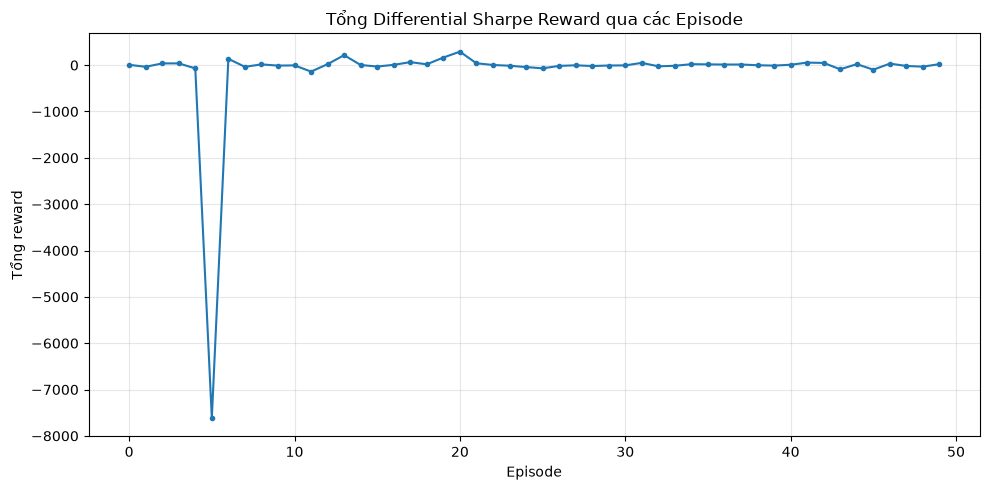

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(rewards_per_episode, marker="o", markersize=3)
plt.title("Tổng Differential Sharpe Reward qua các Episode")
plt.xlabel("Episode")
plt.ylabel("Tổng reward")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_reward.png", dpi=150)
plt.show()


## 7. Lưu model weights cho DA2-RL-03

In [9]:
agent.model.save_weights("dqn_weights.weights.h5")
print("Đã lưu dqn_weights.weights.h5")


Đã lưu dqn_weights.weights.h5
